# Case Study - MEL (DDA-TMT single cell melanoma experiment)

This is case study using the experimental data from [Leduc et al. (2024)](https://www.nature.com/articles/s41596-024-01033-8).

The dataset is available at: https://scp.slavovlab.net/Leduc_et_al_2022.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.collections import LineCollection
from scipy.stats import gaussian_kde

import json
import scipy
import scipy.cluster.hierarchy as sch
import sys
import os
# current_dir = os.getcwd()
# sys.path.append(os.path.join(os.path.dirname(current_dir), 'code'))
import pickle

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from protmapper import uniprot_client
from indra.databases import hgnc_client

from MSquantSim.simulate import simulate_using_copula, simulate_using_tvae, \
    simulate_using_per_protein
from MSquantSim.downstreamanalysis import run_random_forest
from MSquantSim.similarity_scores import plot_corr, compute_dataset_similarity

from causomic.graph_construction.utils import get_neighbor_network
from causomic.graph_construction.indra_queries import get_ids, format_query_results
from sklearn.impute import KNNImputer

import warnings
warnings.filterwarnings('ignore')

import os
from indra_cogex.client import Neo4jClient

client = Neo4jClient(url=os.getenv("API_URL"), 
                        auth=(os.getenv("USER"), 
                            os.getenv("PASSWORD"))
                    )

def hgnc_converter(id, mnemonic_id=False):
    if mnemonic_id:
        uniprot_id = uniprot_client.get_id_from_mnemonic(id)
    else:
        uniprot_id = id
    hgnc_id = uniprot_client.get_hgnc_id(uniprot_id)
    hgnc_name = hgnc_client.get_hgnc_name(hgnc_id)
    return hgnc_name

/Users/kohler.d/miniconda3/envs/MSquantSim_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO: [2026-01-05 15:35:17] indra_cogex.client.neo4j_client - Connected to neo4j graph at bolt://indra-cogex-lb-b954b684556c373c.elb.us-east-1.amazonaws.com:7687


The raw spectra were identified and quantified using MaxQuant. The resulting PSMs were than processed using the methods in MSstatsTMT, including normalization across TMT mixtures using a reference channel and summarization of peptide ions into a single value per protein per channel.

## Process MSstatsTMT Protein-level data

In [2]:
mel_input = pd.read_csv('../../data/MEL_data/MEL_protein_level_data.csv')
mel_input = mel_input.loc[:, ~mel_input.columns.str.contains(';', na=False)]
mel_input.columns = [col.split('|')[1] if '|' in col else col for col in mel_input.columns]
mel_input = mel_input.drop(columns=["Run", "Channel"])

mel_input.columns = [hgnc_converter(i, mnemonic_id=False) if i != "Condition" \
    else "Condition" for i in mel_input.columns]
mel_input.head()

,Condition,ARHGAP10,EFCAB5,FAM186A,ZBTB42,NACA,CROCC2,ACOT7,MYO1C,SNAP23,...,TC2N,MED17,ARGLU1,BTG4,NAGK,SHROOM4,UTP18,ABHD8,BABAM1,HDAC11
0,u,10.449841,11.267802,10.620656,12.056047,10.616000,8.971095,7.622955,9.967160,10.002026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,u,9.988900,9.341027,10.188457,11.560510,10.587988,9.142974,7.911131,9.644867,9.406374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,m,9.731853,8.977844,10.933736,13.109581,10.729755,10.703360,8.243595,10.009776,9.323197,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m,10.151383,9.964322,10.468290,13.302292,10.721968,NaN,8.699114,9.753093,10.364373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m,10.675715,10.823538,11.139793,12.791292,10.218707,7.363879,7.709675,9.950416,10.489982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filter data using missing values and INDRA network

In [3]:
# Count missing values per column
missing_counts = mel_input.isna().sum()
missing_percentages = (missing_counts / len(mel_input))

print(f"Columns with missing values: {(missing_counts > 0).sum()}")
print(f"Total missing values: {missing_counts.sum()}")

# Remove columns with more than 50% missing values
threshold = 0.5
cols_to_keep = missing_percentages[missing_percentages <= threshold].index
mel_input = mel_input[cols_to_keep]

print(f"\nColumns after filtering: {len(mel_input.columns)}")
print(f"Columns removed: {len(missing_percentages) - len(cols_to_keep)}")

Columns with missing values: 3139
Total missing values: 1218425

Columns after filtering: 1148
Columns removed: 1992


In [4]:
# test_network = format_query_results(get_neighbor_network(
#     nodes=get_ids(mel_input.columns, type="gene"),
#     client=client,
#     relation=["IncreaseAmount", "DecreaseAmount"],
#     upstream=True,
#     downstream=True,
#     minimum_evidence_count=5,
#     filter_all_nodes=True))
with open('../../data/MEL_data/INDRA_network_MEL.pkl', 'rb') as f:
    test_network = pickle.load(f)

filtered = test_network.loc[:, ["source", "target"]].drop_duplicates()

G = nx.DiGraph()
for i in range(len(filtered)):
    G.add_edge(filtered.iloc[i]["source"], filtered.iloc[i]["target"])

components = list(nx.weakly_connected_components(G))
max_component = max(components, key=len)
print(f"Largest connected component size: {len(max_component)} nodes")

cols = [c for c in mel_input.columns if (c == 'Condition' or c in max_component)]
mel_input = mel_input.loc[:, cols]

Largest connected component size: 124 nodes


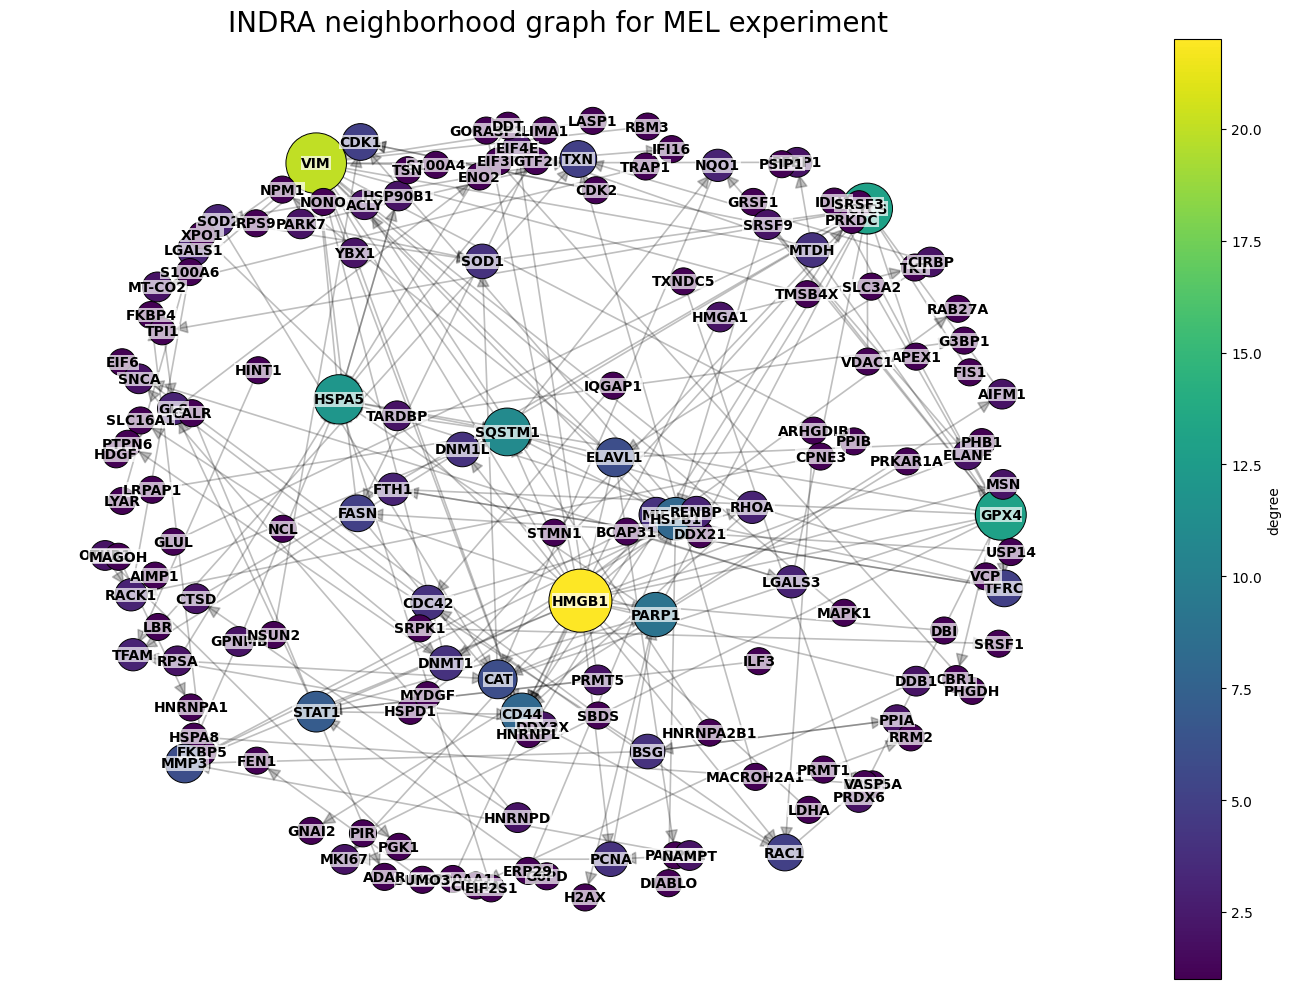

In [5]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=.8)  # slightly more spacing
deg = dict(G.degree())
# Bigger nodes overall
node_sizes = [300 + deg[n] * 80 for n in G.nodes()]
node_colors = [deg[n] for n in G.nodes()]
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.25,
    arrowsize=20,
    width=1.2
)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.7
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.7,
        pad=0.2
    )
)
plt.colorbar(nodes, label="degree")
plt.title("INDRA neighborhood graph for MEL experiment", fontsize=20)
plt.axis("off")
plt.tight_layout()
plt.show()

### Impute missing values

In [6]:
# Keep original column order
orig_cols = mel_input.columns.tolist()

# Split numeric and non-numeric columns
numeric_cols = [c for c in orig_cols if pd.api.types.is_numeric_dtype(mel_input[c])]
non_numeric_cols = [c for c in orig_cols if c not in numeric_cols]

# Report missing values before imputation
print("Missing values before imputation (numeric cols):")
print(mel_input[numeric_cols].isna().sum().sum())

# KNN imputation
imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputed_array = imputer.fit_transform(mel_input[numeric_cols])

# Build imputed DataFrame and restore original column order
imputed_numeric = pd.DataFrame(imputed_array, columns=numeric_cols, index=mel_input.index)
mel_input = pd.concat([mel_input[non_numeric_cols], imputed_numeric], axis=1)[orig_cols]

# Report missing values after imputation
print("\nMissing values after imputation (numeric cols):")
print(mel_input[numeric_cols].isna().sum().sum())

Missing values before imputation (numeric cols):
10496

Missing values after imputation (numeric cols):
0


### Split data for simulation

In [7]:
# Split into health and disease
mel_healthy = mel_input[mel_input['Condition'] == "u"].drop(columns=['Condition'])
mel_disease = mel_input[mel_input['Condition'] == "m"].drop(columns=['Condition'])

## Copula

### Single simulation

In [8]:
copula_sim_mel_healthy_single = simulate_using_copula(
    mel_healthy, num_simulations=1, 
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_mel_disease_single = simulate_using_copula(
    mel_disease, num_simulations=1, 
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-17 11:19:30] copulas.multivariate.gaussian - Fitting GaussianMultivariate()
INFO: [2025-12-17 11:19:53] copulas.multivariate.gaussian - Fitting GaussianMultivariate()


### Multiple simulations

In [8]:
n_sims = 100

copula_sim_mel_healthy_multi = simulate_using_copula(
    mel_healthy, num_simulations=n_sims, 
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_mel_disease_multi = simulate_using_copula(
    mel_disease, num_simulations=n_sims, 
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

Running copula simulations: 100%|██████████| 100/100 [04:41<00:00,  2.81s/it]


In [ ]:
with open("../../data/MEL_data/results/COPULA_MEL_healthy.pkl", "wb") as f:
    pickle.dump(copula_sim_mel_healthy_multi, f)
with open("../../data/MEL_data/results/COPULA_MEL_disease.pkl", "wb") as f:
    pickle.dump(copula_sim_mel_disease_multi, f)

## TVAE

### Single simulation

In [ ]:
tvae_sim_mel_healthy_single = simulate_using_tvae(
    mel_healthy, None, num_simulations=1,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_mel_disease_single = simulate_using_tvae(
    mel_disease, None, num_simulations=1,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-16 10:12:27] sdv.metadata.single_table - Detected metadata:
INFO: [2025-12-16 10:12:27] sdv.metadata.single_table - {
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "DDX3X": {
            "sdtype": "numerical"
        },
        "PIR": {
            "sdtype": "numerical"
        },
        "PRMT5": {
            "sdtype": "numerical"
        },
        "XPO1": {
            "sdtype": "numerical"
        },
        "CPNE3": {
            "sdtype": "numerical"
        },
        "MACROH2A1": {
            "sdtype": "numerical"
        },
        "PSIP1": {
            "sdtype": "numerical"
        },
        "IDH1": {
            "sdtype": "numerical"
        },
        "GLS": {
            "sdtype": "numerical"
        },
        "AIFM1": {
            "sdtype": "numerical"
        },
        "LDHA": {
            "sdtype": "numerical"
        },
        "MT-CO2": {
            "sdtype": "numerical"
        },
        "SOD1": {
            "sdtyp

### Multiple simulations

In [10]:
n_sims = 100

tvae_sim_mel_healthy_multi = simulate_using_tvae(
    mel_healthy, None, num_simulations=n_sims,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_mel_disease_multi = simulate_using_tvae(
    mel_disease, None, num_simulations=n_sims,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-17 12:41:03] sdv.metadata.single_table - Detected metadata:
INFO: [2025-12-17 12:41:03] sdv.metadata.single_table - {
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "DDX3X": {
            "sdtype": "numerical"
        },
        "PIR": {
            "sdtype": "numerical"
        },
        "PRMT5": {
            "sdtype": "numerical"
        },
        "XPO1": {
            "sdtype": "numerical"
        },
        "CPNE3": {
            "sdtype": "numerical"
        },
        "MACROH2A1": {
            "sdtype": "numerical"
        },
        "PSIP1": {
            "sdtype": "numerical"
        },
        "IDH1": {
            "sdtype": "numerical"
        },
        "GLS": {
            "sdtype": "numerical"
        },
        "AIFM1": {
            "sdtype": "numerical"
        },
        "LDHA": {
            "sdtype": "numerical"
        },
        "MT-CO2": {
            "sdtype": "numerical"
        },
        "SOD1": {
            "sdtyp

In [ ]:
with open("../../data/MEL_data/results/TVAE_MEL_healthy.pkl", "wb") as f:
    pickle.dump(tvae_sim_mel_healthy_multi, f)
with open("../../data/MEL_data/results/TVAE_MEL_disease.pkl", "wb") as f:
    pickle.dump(tvae_sim_mel_disease_multi, f)

## Per-protein

### Single simulation

In [18]:
pprotein_sim_mel_healthy_single = simulate_using_per_protein(
    mel_healthy, num_simulations=1,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_mel_disease_single = simulate_using_per_protein(
    mel_disease, num_simulations=1,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [19]:
n_sims = 100

pprotein_sim_mel_healthy_multi = simulate_using_per_protein(
    mel_healthy, num_simulations=n_sims,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_mel_disease_multi = simulate_using_per_protein(
    mel_disease, num_simulations=n_sims,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)












100%|██████████| 100/100 [00:00<00:00, 208.07it/s]














100%|██████████| 100/100 [00:00<00:00, 310.71it/s]


In [ ]:
with open("../../data/MEL_data/results/PPROTEIN_MEL_healthy.pkl", "wb") as f:
    pickle.dump(pprotein_sim_mel_healthy_multi, f)
with open("../../data/MEL_data/results/PPROTEIN_MEL_disease.pkl", "wb") as f:
    pickle.dump(pprotein_sim_mel_disease_multi, f)

## Evaluate simulations


In [8]:
with open("../../data/MEL_data/results/COPULA_MEL_healthy.pkl", "rb") as f:
    copula_sim_mel_healthy_multi = pickle.load(f)
with open("../../data/MEL_data/results/COPULA_MEL_disease.pkl", "rb") as f:
    copula_sim_mel_disease_multi = pickle.load(f)
with open("../../data/MEL_data/results/TVAE_MEL_healthy.pkl", "rb") as f:
    tvae_sim_mel_healthy_multi = pickle.load(f)
with open("../../data/MEL_data/results/TVAE_MEL_disease.pkl", "rb") as f:
    tvae_sim_mel_disease_multi = pickle.load(f)
with open("../../data/MEL_data/results/PPROTEIN_MEL_healthy.pkl", "rb") as f:
    pprotein_sim_mel_healthy_multi = pickle.load(f)
with open("../../data/MEL_data/results/PPROTEIN_MEL_disease.pkl", "rb") as f:
    pprotein_sim_mel_disease_multi = pickle.load(f)

### Two protein comparison

In [9]:
def joint_scatter_with_marginal_kdes(
    df,
    x_col,
    y_col,
    hue_col,
    *,
    figsize=(5.2, 5.2),
    point_size=28,
    point_alpha=0.70,
    kde_lw=2.2,
    kde_gridsize=256,
    tick_fs=20,
    label_fs=24,
    density_fs=22,
    inner_tick_fs=1,
    remove_legend=True,
    legend_kwargs=None,
    dropna=True,
    colors=None,
):
    """
    Matplotlib-only joint scatter with per-condition marginal KDEs.

    Parameters
    ----------
    df : pandas.DataFrame
    x_col, y_col, hue_col : str
        Column names for x, y, and grouping (condition).
    figsize : tuple
    point_size : float
    point_alpha : float
    kde_lw : float
    kde_gridsize : int
    tick_fs, label_fs, density_fs, inner_tick_fs : int
    remove_legend : bool
    legend_kwargs : dict or None
    dropna : bool
    colors : dict or None
        Optional mapping {condition_value: color_hex}. If None, uses
        Okabe–Ito colorblind-friendly palette.

    Returns
    -------
    fig, (ax_kde_x, ax_scatter, ax_kde_y)
    """
    # Colorblind-friendly palette (Okabe–Ito)
    okabe_ito = [
        "#0072B2", "#D55E00", "#009E73", "#CC79A7",
        "#F0E442", "#56B4E9", "#E69F00", "#000000",
    ]

    use_df = df[[x_col, y_col, hue_col]].copy()
    if dropna:
        use_df = use_df.dropna()

    x = use_df[x_col].to_numpy()
    y = use_df[y_col].to_numpy()
    hue = use_df[hue_col].to_numpy()

    conds = np.unique(hue)
    if colors is None:
        color_map = {c: okabe_ito[i % len(okabe_ito)] for i, c in enumerate(conds)}
    else:
        color_map = dict(colors)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=2,
        ncols=2,
        height_ratios=[1.1, 4],
        width_ratios=[4, 1.1],
        hspace=0.15,
        wspace=0.15,
    )

    ax_kde_x = fig.add_subplot(gs[0, 0])
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_kde_y = fig.add_subplot(gs[1, 1])

    # Scatter
    for c in conds:
        m = hue == c
        ax_scatter.scatter(
            x[m],
            y[m],
            s=point_size,
            alpha=point_alpha,
            edgecolor="none",
            color=color_map[c],
            label=str(c),
        )

    ax_scatter.set_xlabel(x_col, fontsize=label_fs)
    ax_scatter.set_ylabel(y_col, fontsize=label_fs)
    ax_scatter.tick_params(axis="both", which="major", labelsize=tick_fs)

    # KDEs
    def _plot_kde(ax, values, grid, color):
        kde = gaussian_kde(values)
        ax.plot(grid, kde(grid), lw=kde_lw, color=color)

    x_grid = np.linspace(np.min(x), np.max(x), kde_gridsize)
    for c in conds:
        v = x[hue == c]
        if v.size > 1:
            _plot_kde(ax_kde_x, v, x_grid, color_map[c])

    ax_kde_x.set_ylabel("Density", fontsize=density_fs)
    ax_kde_x.tick_params(axis="both", which="major", labelsize=inner_tick_fs)
    ax_kde_x.set_xticklabels([])

    y_grid = np.linspace(np.min(y), np.max(y), kde_gridsize)
    for c in conds:
        v = y[hue == c]
        if v.size > 1:
            kde = gaussian_kde(v)
            ax_kde_y.plot(kde(y_grid), y_grid, lw=kde_lw, color=color_map[c])

    ax_kde_y.set_xlabel("Density", fontsize=density_fs)
    ax_kde_y.tick_params(axis="both", which="major", labelsize=inner_tick_fs)
    ax_kde_y.set_yticklabels([])

    # Spines
    for ax in (ax_kde_x, ax_scatter, ax_kde_y):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Legend
    if remove_legend:
        leg = ax_scatter.get_legend()
        if leg is not None:
            leg.remove()
    else:
        if legend_kwargs is None:
            legend_kwargs = dict(frameon=False, fontsize=inner_tick_fs, loc="best")
        ax_scatter.legend(**legend_kwargs)

    return fig, (ax_kde_x, ax_scatter, ax_kde_y)

#### Experimental data

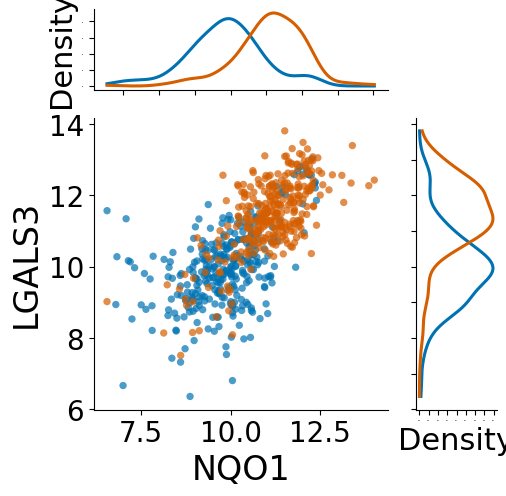

In [10]:
protein1 = "NQO1"
protein2 = "LGALS3"
mel_input["Condition"] = mel_input["Condition"].map({"u": 0, "m": 1 }) # For colors

fig, axes = joint_scatter_with_marginal_kdes(
    mel_input, protein1, protein2, "Condition"
)
plt.show()

#### Per-protein

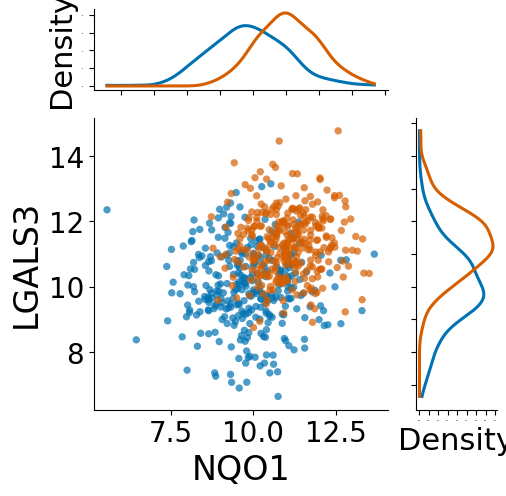

In [11]:
simpp0 = pprotein_sim_mel_healthy_multi[0]
simpp1 = pprotein_sim_mel_disease_multi[0]
merged_df = pd.merge(simpp0, simpp1, how='outer', indicator=True)
merged_df['Condition'] = merged_df['_merge'].map({ 'left_only': 0, 'right_only': 1})
merged_df = merged_df.drop('_merge', axis=1)
fig, axes = joint_scatter_with_marginal_kdes(
    merged_df, protein1, protein2, "Condition"
)
plt.show()

#### VAE

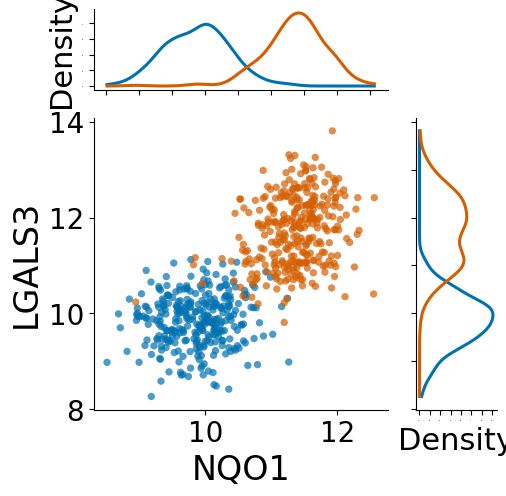

In [12]:
simtvae0 = tvae_sim_mel_healthy_multi[0]
simtvae1 = tvae_sim_mel_disease_multi[0]
merged_df = pd.merge(simtvae0, simtvae1, how='outer', indicator=True)
merged_df['Condition'] = merged_df['_merge'].map({ 'left_only': 0, 'right_only': 1})
merged_df = merged_df.drop('_merge', axis=1)
fig, axes = joint_scatter_with_marginal_kdes(
    merged_df, protein1, protein2, "Condition"
)
plt.show()

#### Copula

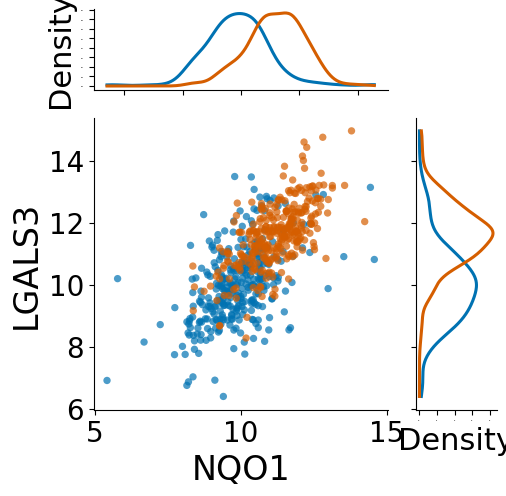

In [13]:
simco0 = copula_sim_mel_healthy_multi[0]
simco1 = copula_sim_mel_disease_multi[0]
merged_df = pd.merge(simco0, simco1, how='outer', indicator=True)
merged_df['Condition'] = merged_df['_merge'].map({ 'left_only': 0, 'right_only': 1})
merged_df = merged_df.drop('_merge', axis=1)
fig, axes = joint_scatter_with_marginal_kdes(
    merged_df, protein1, protein2, "Condition"
)
plt.show()

### Correlation Heatmaps

#### Experimental data

In [14]:
def plot_corr(
    df: pd.DataFrame,
    size: float = 10,
    method: str = "pearson",
    cmap: str = "RdBu_r",
):
    """
    Professional, label-free correlation heatmap (lower triangle),
    optimized for large feature sets and colorblind safety.
    """
    # Keep numeric columns only
    x = df.select_dtypes(include=[np.number])
    if x.shape[1] < 2:
        raise ValueError("Need at least 2 numeric columns.")

    corr = x.corr(method=method)

    # Mask upper triangle + diagonal
    mask = np.triu(np.ones_like(corr, dtype=bool))
    corr_plot = corr.mask(mask)

    fig, ax = plt.subplots(figsize=(size, size), dpi=150)

    im = ax.imshow(
        corr_plot.to_numpy(),
        vmin=-1,
        vmax=1,
        cmap=cmap,
        interpolation="nearest",
    )

    # Remove all ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Optional subtle grid for structure (can remove if you want ultra-clean)
    n = corr.shape[0]
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=0.4, alpha=.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Correlation", fontsize=11)

    fig.tight_layout()
    return fig, ax

(<Figure size 750x750 with 2 Axes>, <Axes: >)

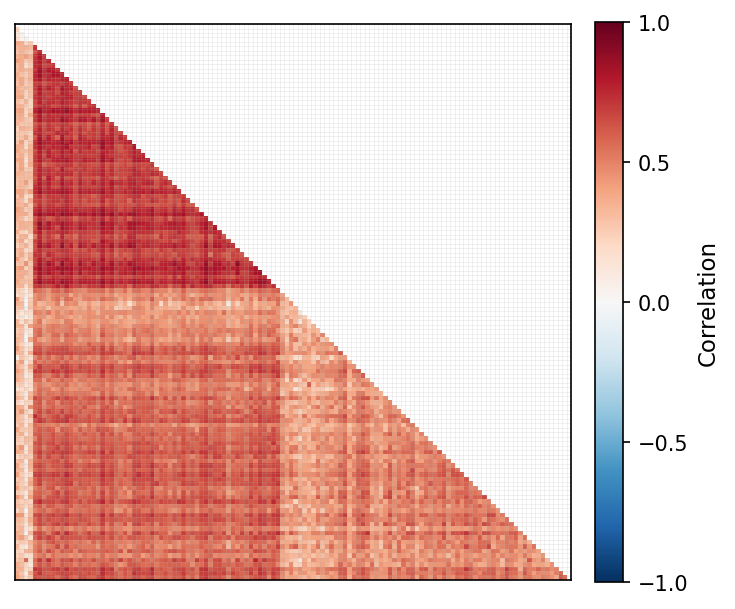

In [15]:
mono_df = mel_input[mel_input['Condition'] == 0].drop(columns='Condition')
X = mono_df.corr().values
X[np.isnan(X)]= 0
d = sch.distance.pdist(X)   
L = sch.linkage(d, method='complete')
ind = sch.fcluster(L, 0.5*d.max(), 'distance')
columns = [mono_df.columns.tolist()[i] for i in list((np.argsort(ind)))]
mono_df = mono_df.reindex(columns, axis=1)
plot_corr(mono_df, size =5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

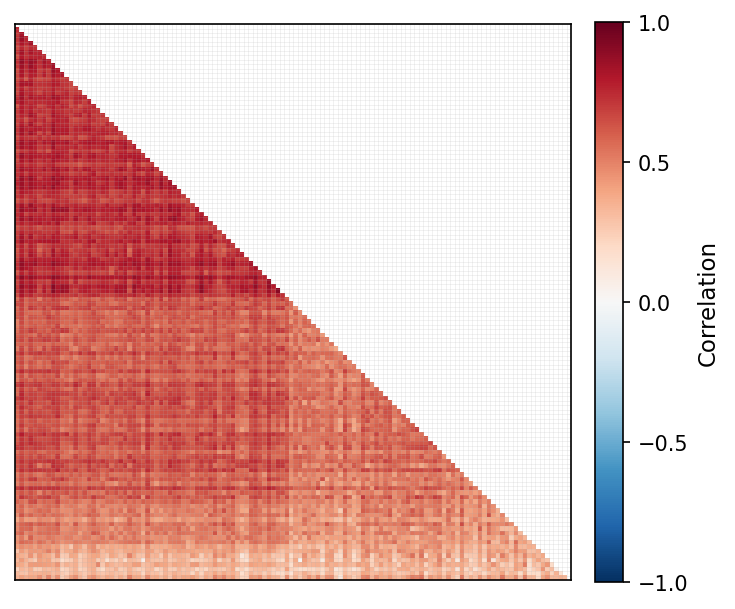

In [16]:
mel_df = mel_input[mel_input['Condition'] == 1].drop(columns='Condition')
X = mel_df.corr().values
X[np.isnan(X)]= 0
d = sch.distance.pdist(X)   
L = sch.linkage(d, method='complete')
ind = sch.fcluster(L, 0.5*d.max(), 'distance')
columns = [mel_df.columns.tolist()[i] for i in list((np.argsort(ind)))]
mel_df = mel_df.reindex(columns, axis=1)
plot_corr(mel_df, size =5)

#### Per-protein

(<Figure size 750x750 with 2 Axes>, <Axes: >)

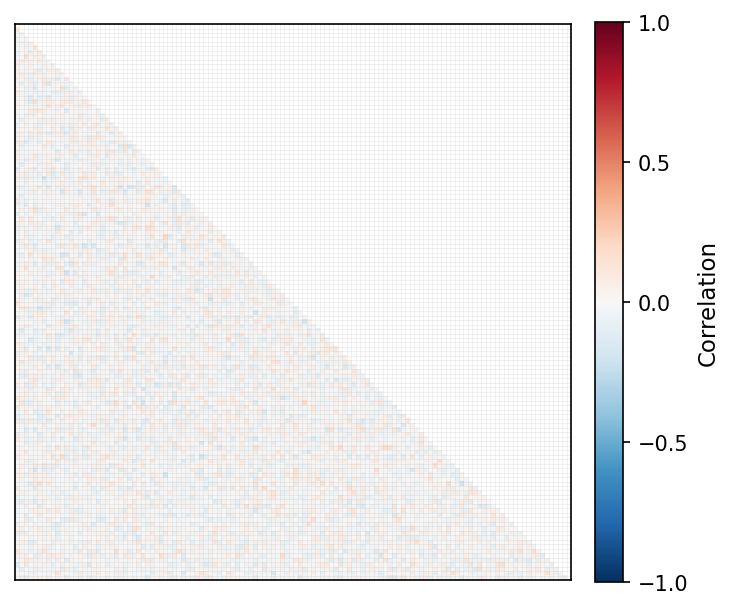

In [17]:
simpp0 = simpp0.reindex(columns, axis=1)
plot_corr(simpp0, size = 5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

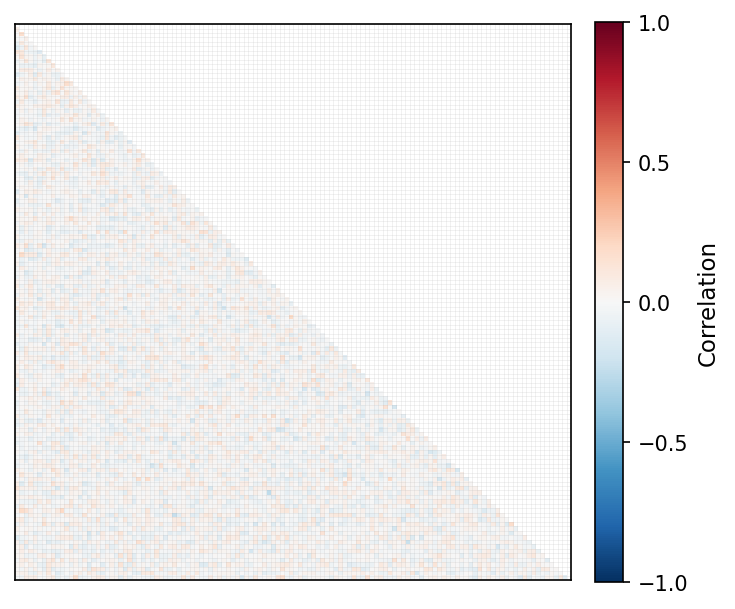

In [18]:
simpp1 = simpp1.reindex(columns, axis=1)
plot_corr(simpp1, size = 5)

#### VAE

(<Figure size 750x750 with 2 Axes>, <Axes: >)

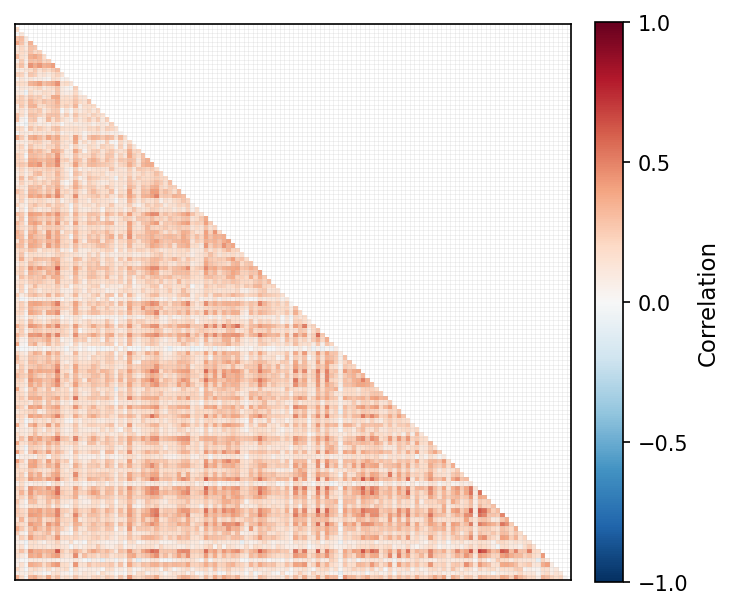

In [19]:
simtvae0 = simtvae0.reindex(columns, axis=1)
plot_corr(simtvae0, size = 5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

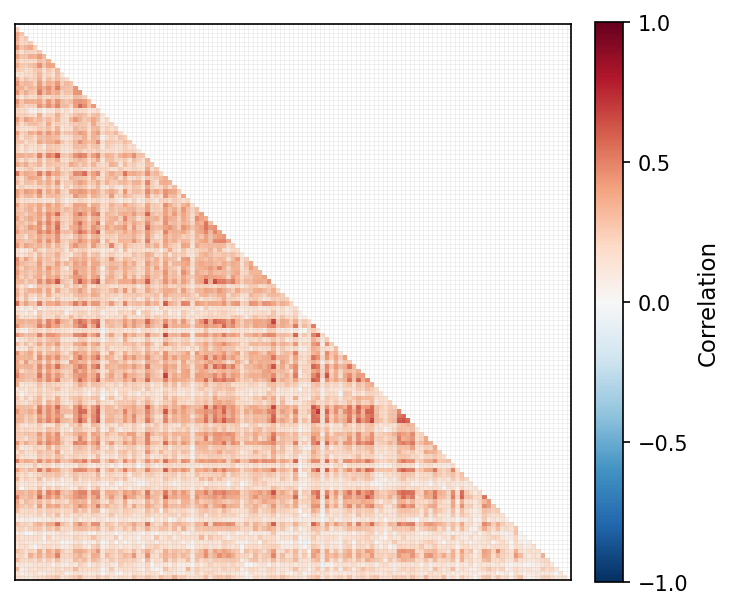

In [20]:
simtvae1 = simtvae1.reindex(columns, axis=1)
plot_corr(simtvae1, size = 5)

#### Copula

(<Figure size 750x750 with 2 Axes>, <Axes: >)

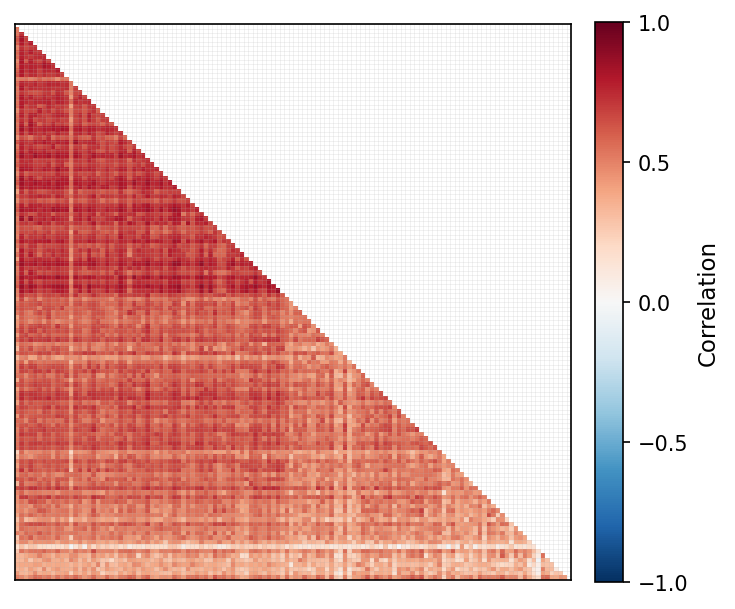

In [21]:
simco0 = simco0.reindex(columns, axis=1)
plot_corr(simco0, size = 5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

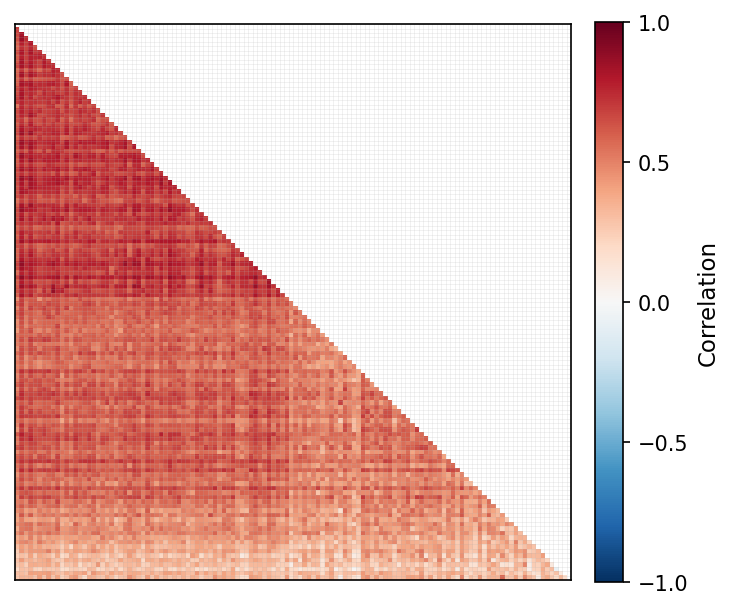

In [22]:
simco1 = simco1.reindex(columns, axis=1)
plot_corr(simco1, size = 5)

## Correlation statistics

### Per-protein

In [ ]:
copula_sim_mel_healthy_multi
copula_sim_mel_disease_multi
tvae_sim_mel_healthy_multi
tvae_sim_mel_disease_multi
pprotein_sim_mel_healthy_multi
pprotein_sim_mel_disease_multi

mel_healthy
mel_disease

In [14]:
scores = compute_dataset_similarity(copula_sim_mel_healthy_multi[1], mel_healthy, min_pairs=3)
print(scores)
print(scores.details)

SimilarityScores(S_basic=0.06558591234233865, S_corr=0.06606876738240977, S_mirr=0.056146823302593865, S_pca=0.5776775475429103, SS=0.19136976264256317, details={'pearson_corr_corresponding': 0.06606876738240977, 'spearman_corr_corresponding': 0.06510305730226754, 'mean_corr_corresponding': 0.06558591234233865, 'mirror_corr_mean_all_pairs': 0.056146823302593865, 'pca_explained_var_pc1_pc2': 0.5776775475429103, 'num_common_cols_used': 124.0})
{'pearson_corr_corresponding': 0.06606876738240977, 'spearman_corr_corresponding': 0.06510305730226754, 'mean_corr_corresponding': 0.06558591234233865, 'mirror_corr_mean_all_pairs': 0.056146823302593865, 'pca_explained_var_pc1_pc2': 0.5776775475429103, 'num_common_cols_used': 124.0}


<Axes: >

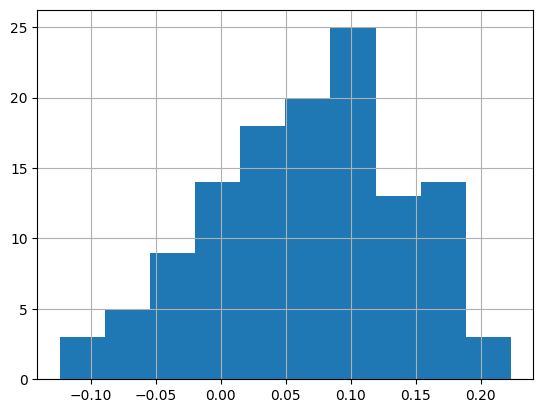

In [18]:
copula_sim_mel_healthy_multi[1].corrwith(mel_healthy).hist()

In [20]:
from table_evaluator import TableEvaluator

In [22]:
merged_df = pd.merge(copula_sim_mel_healthy_multi[0], 
                     copula_sim_mel_disease_multi[0], 
                     how='outer', indicator=True)

In [24]:
condition_mapping = {'left_only': 0, 'right_only': 1, 'both': 2}
merged_df['Condition'] = merged_df['_merge'].map(condition_mapping)
merged_df = merged_df.drop('_merge', axis=1)


In [27]:
reference = pd.merge(mel_healthy, mel_disease, 
                     how='outer', indicator=True)

reference['Condition'] = reference['_merge'].map(condition_mapping)
reference = reference.drop('_merge', axis=1)

In [42]:
table_evaluator = TableEvaluator(reference, merged_df, cat_cols=['Condition'], metric="spearmanr")

In [43]:
table_evaluator.evaluate(target_col='Condition')


Classifier F1-scores and their Jaccard similarities::
    real   fake
0 0.9567 0.9567

Privacy results:
                                         result
Duplicate rows between sets (real/fake)  (0, 0)
nearest neighbor mean                    7.8202
nearest neighbor std                     1.2499

Miscellaneous results:
                                  Result
Column Correlation Distance RMSE  0.0271
Column Correlation distance MAE   0.0214

Results:
                                                result
Basic statistics                                0.9952
Correlation column correlations                 0.9815
Mean Correlation between fake and real columns  0.9863
1 - MAPE Estimator results                      0.9567
Similarity Score                                0.9799


{'Basic statistics': 0.9951586350950277,
 'Correlation column correlations': 0.9814819848002104,
 'Mean Correlation between fake and real columns': 0.9862888951149094,
 '1 - MAPE Estimator results': 0.9567075700953472,
 'Similarity Score': 0.9799092712763736}

In [45]:
np.mean([.9952, .9815, .9863, .9567])

0.979925

### TVAE

### Copula

##  Planning. Use simulations to plan future experiments

#### Class Prediction

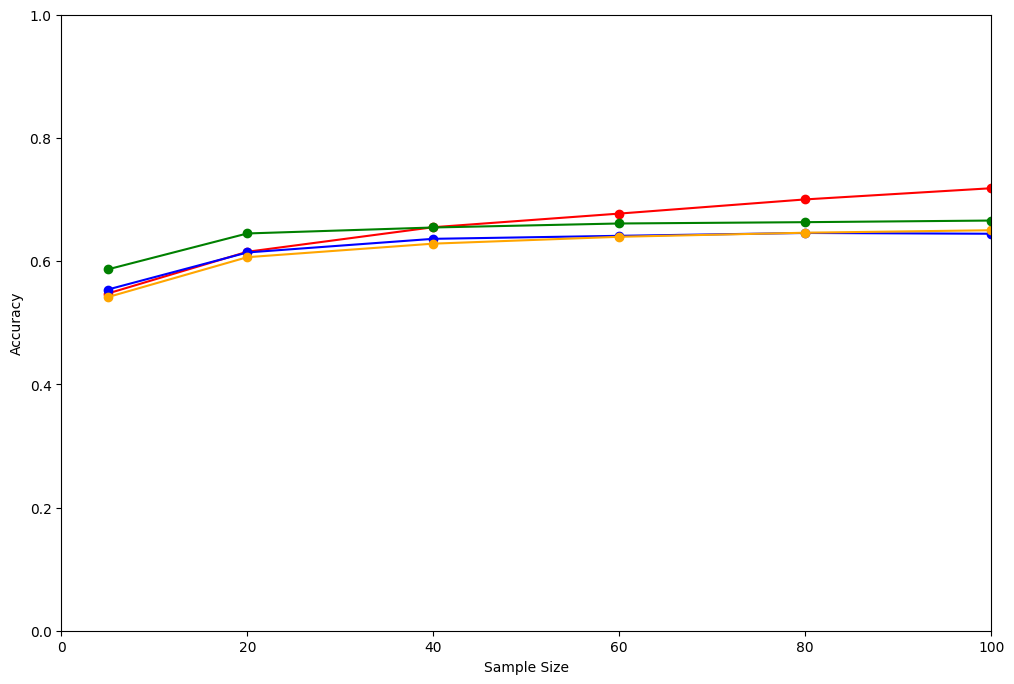

In [5]:
rfaccuracy = pd.read_csv('../casestudy/mel/melrfaccuracy.csv')

crc_data_val = rfaccuracy

font = {'weight' : 'bold',
        'size'   : 22}

# matplotlib.rc('font', **font)

plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental',marker='o', color='red')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='PP',marker='o', color='blue')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='CO',marker='o', color='orange')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Accuracy')

plt.ylim(0.0, 1.0)
plt.xlim(0,100)
plt.show()


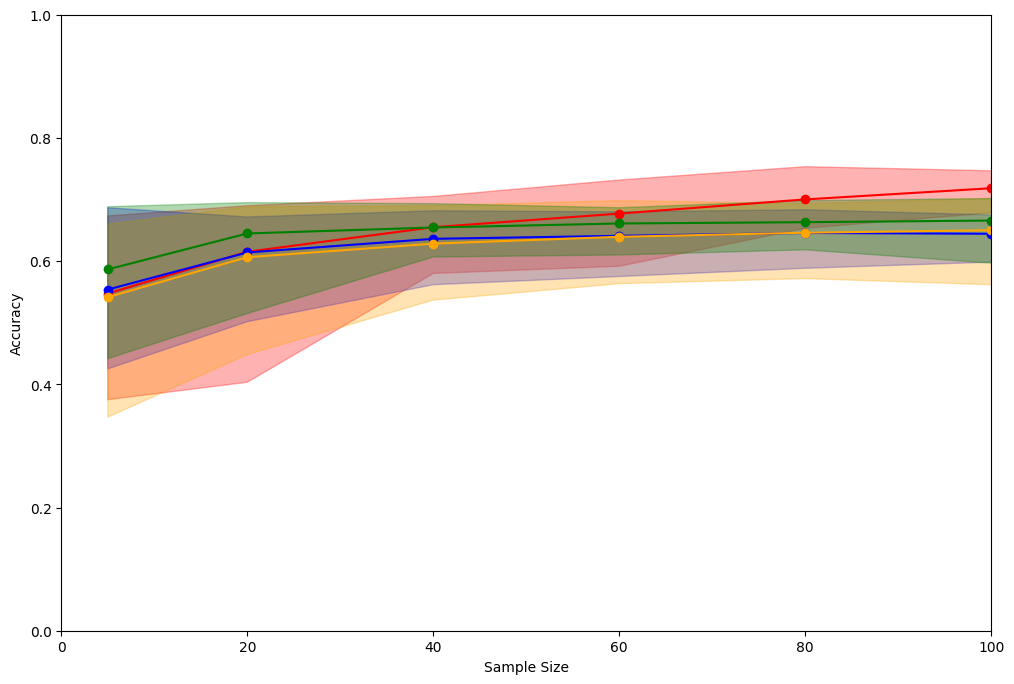

In [6]:
font = {'weight' : 'bold',
        'size'   : 22}

# matplotlib.rc('font', **font)

plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental',marker='o', color='red')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='PP',marker='o', color='blue')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='CO',marker='o', color='orange')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.xlim(0,100)
plt.show()


##### Class Discovery

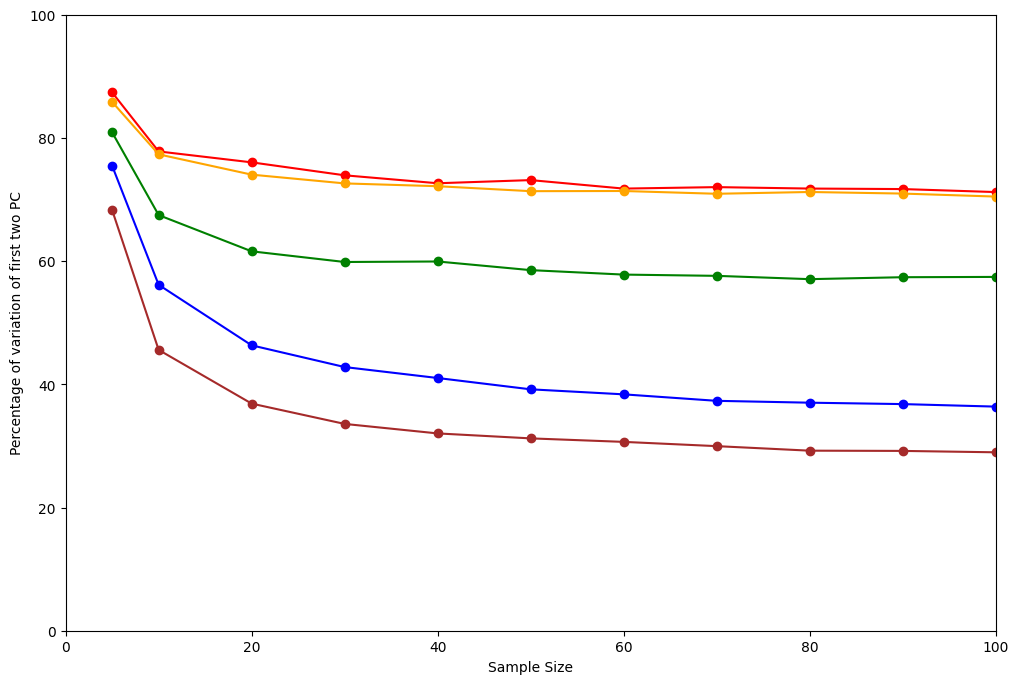

In [9]:
pcaaccuracy = pd.read_csv('../casestudy/mel/melpcanew.csv')
crc_data_val = pcaaccuracy

font = {'weight' : 'bold',
        'size'   : 22}


plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental Train',marker='o', color='red')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)

plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy v'],label='Experimental Validation',marker='o', color='brown')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min v'], crc_data_val['max v'], color='brown', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='Per-Protein',marker='o', color='blue')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='Copula',marker='o', color='orange')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Percentage of variation of first two PC')

plt.ylim(0, 100)
plt.xlim(0,100)
plt.show()


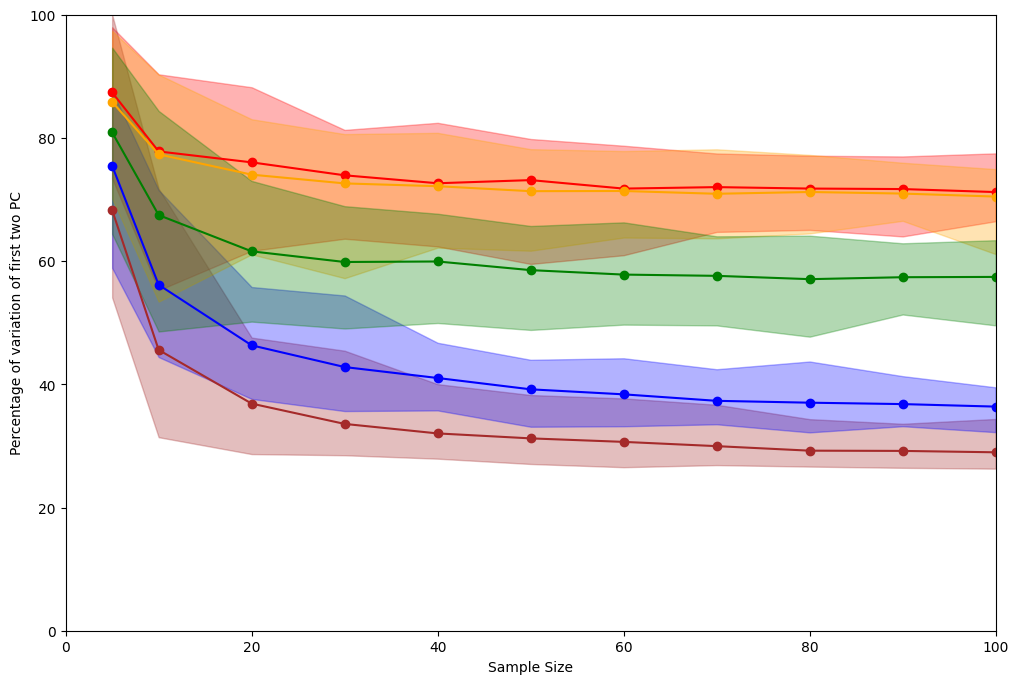

In [10]:

plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental Train',marker='o', color='red')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)

plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy v'],label='Experimental Validation',marker='o', color='brown')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min v'], crc_data_val['max v'], color='brown', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='Per-Protein',marker='o', color='blue')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='Copula',marker='o', color='orange')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Percentage of variation of first two PC')

plt.ylim(0, 100)
plt.xlim(0,100)
plt.show()


##### Class Comparison

In [32]:
adjusted_p_values = {}
adjusted_p_values_pp = {}
adjusted_p_values_co = {}
adjusted_p_values_tvae = {}
dicts = {'real_adjust': adjusted_p_values, 'pp_adjust': adjusted_p_values_pp, 'co_adjust': adjusted_p_values_co, 'tvae_adjust': adjusted_p_values_tvae}  # Add more dictionaries as needed

# Load each JSON file and update the corresponding dictionary
for key, value in dicts.items():
    file_path = f'../casestudy/mel/pval/{key}.json'
    with open(file_path, 'r') as json_file:
        value.update(json.load(json_file))
sample_sizes=[5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]

real = []
pp = []
co = []
tvae = []
realmin = []
realmax = []
ppmin = []
ppmax = []
comin = []
comax = []
tvaemin = []
tvaemax = []

col = 'TYB10_HUMAN'

cols = col
for s in sample_sizes:
    s = str(s)
    real.append(np.median(adjusted_p_values[s][col]))
    pp.append(np.median(adjusted_p_values_pp[s][col]))
    co.append(np.median(adjusted_p_values_co[s][col]))
    tvae.append(np.median(adjusted_p_values_tvae[s][col]))
    realmin.append(np.min(adjusted_p_values[s][col]))
    realmax.append(np.max(adjusted_p_values[s][col]))
    ppmin.append(np.min(adjusted_p_values_pp[s][col]))
    ppmax.append(np.max(adjusted_p_values_pp[s][col]))
    comin.append(np.min(adjusted_p_values_co[s][col]))
    comax.append(np.max(adjusted_p_values_co[s][col])) 
    tvaemin.append(np.min(adjusted_p_values_tvae[s][col]))
    tvaemax.append(np.max(adjusted_p_values_tvae[s][col]))

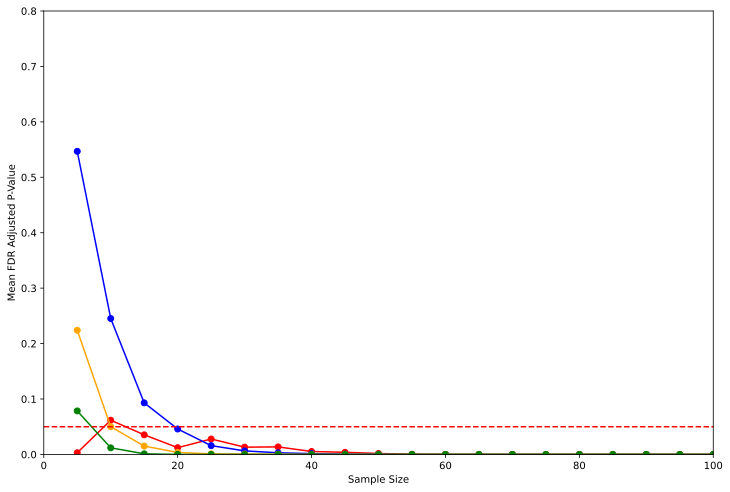

In [34]:
# Plot mean p-value vs sample size for each column
plt.figure(figsize=(12, 8))
font = {'weight' : 'bold',
        'size'   : 22}

plt.plot(sample_sizes, real, marker='o', label='Experimental', color='red', linestyle='-')
# plt.fill_between(sample_sizes, realmin, realmax, color='red', alpha=0.3)

plt.plot(sample_sizes, pp, marker='o', label='Per-Protein', color='blue', linestyle='-')
# plt.fill_between(sample_sizes, ppmin, ppmax, color='blue', alpha=0.3)

plt.plot(sample_sizes, co, marker='o', label='Copula', color='orange', linestyle='-')
# plt.fill_between(sample_sizes, comin, comax, color='orange', alpha=0.3)

plt.plot(sample_sizes, tvae, marker='o', label='TVAE', color='green', linestyle='-')
# plt.fill_between(sample_sizes, tvaemin, tvaemax, color='green', alpha=0.3)

plt.axhline(y=0.05, color='red', linestyle='--')

plt.xlabel('Sample Size')
plt.ylabel('Mean FDR Adjusted P-Value')
plt.ylim(0.0,0.8)
plt.xlim(0,100)
plt.show()

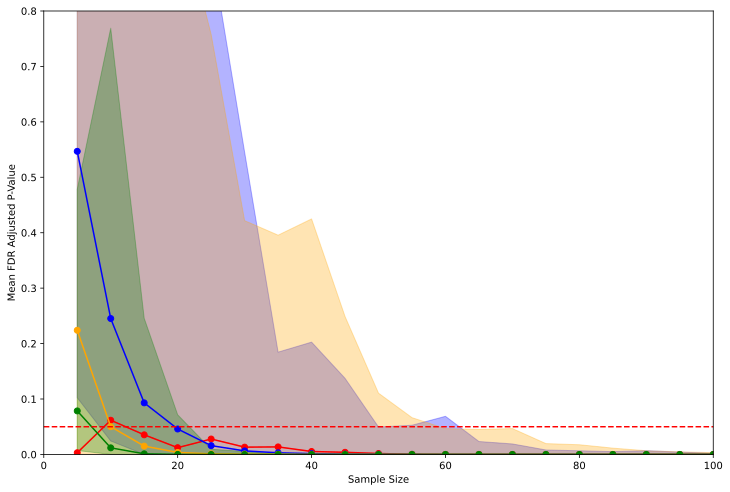

In [35]:
# Plot mean p-value vs sample size for each column
plt.figure(figsize=(12, 8))
font = {'weight' : 'bold',
        'size'   : 22}

plt.plot(sample_sizes, real, marker='o', label='Experimental', color='red', linestyle='-')
plt.fill_between(sample_sizes, realmin, realmax, color='red', alpha=0.3)

plt.plot(sample_sizes, pp, marker='o', label='Per-Protein', color='blue', linestyle='-')
plt.fill_between(sample_sizes, ppmin, ppmax, color='blue', alpha=0.3)

plt.plot(sample_sizes, co, marker='o', label='Copula', color='orange', linestyle='-')
plt.fill_between(sample_sizes, comin, comax, color='orange', alpha=0.3)

plt.plot(sample_sizes, tvae, marker='o', label='TVAE', color='green', linestyle='-')
plt.fill_between(sample_sizes, tvaemin, tvaemax, color='green', alpha=0.3)

plt.axhline(y=0.05, color='red', linestyle='--')

plt.xlabel('Sample Size')
plt.ylabel('Mean FDR Adjusted P-Value')
plt.ylim(0.0,0.8)
plt.xlim(0,100)
plt.show()